In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"D:\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
print("Shape:", df.shape)
df.info()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [3]:
missing_values = df.isnull().sum()
print(missing_values)

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:
df_cleaned = df.dropna()
print("Shape after removing missing values:")
print(df_cleaned.shape)

Shape after removing missing values:
(200, 5)


In [5]:
duplicates = df_cleaned.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [6]:
df_cleaned = df_cleaned.drop_duplicates()

print("Shape after removing duplicates:")
print(df_cleaned.shape)

Shape after removing duplicates:
(200, 5)


In [7]:
Q1 = df_cleaned['Annual Income (k$)'].quantile(0.25)
Q3 = df_cleaned['Annual Income (k$)'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_cleaned[
    (df_cleaned['Annual Income (k$)'] < lower) |
    (df_cleaned['Annual Income (k$)'] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 2


In [8]:
summary = df_cleaned.describe()
print(summary)

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


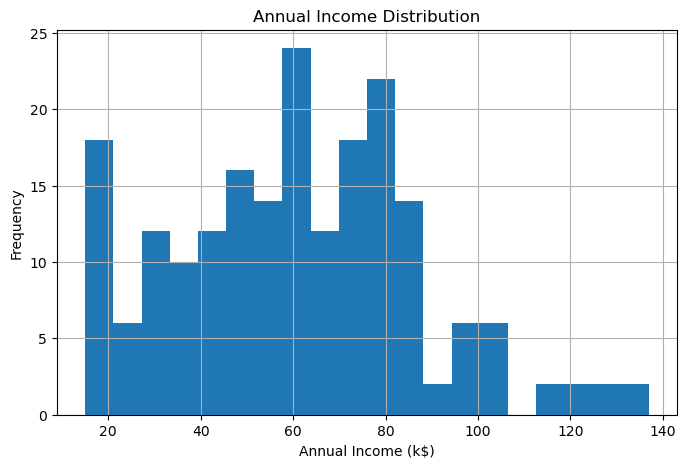

In [9]:
plt.figure(figsize=(8,5))

df_cleaned['Annual Income (k$)'].hist(bins=20)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')

plt.show()

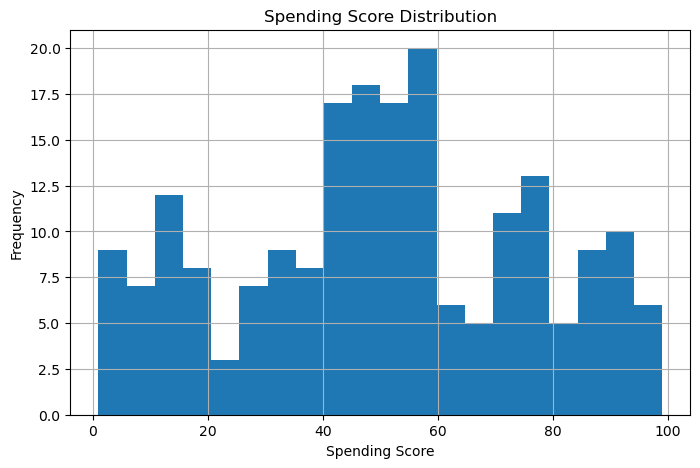

In [10]:
plt.figure(figsize=(8,5))

df_cleaned['Spending Score (1-100)'].hist(bins=20)

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')

plt.show()

In [11]:
summary.to_csv("Automated_Report.csv")

print("Automated Report Generated Successfully")

Automated Report Generated Successfully
